<a href="https://colab.research.google.com/github/jrivasgo/TFG-Algoritmos-de-clasificacio-de-radiografias-de-torax/blob/main/autancoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



carga las herramientas necesarias:

TensorFlow para crear y entrenar el autoencoder.
NumPy y pandas para manipular datos.
Matplotlib para generar gráficas.
Scikit-learn para dividir los datos, entrenar Random Forest y evaluar resultados.
hashlib para detectar imágenes duplicadas exactas.
joblib para guardar el Random Forest.

In [ ]:
import hashlib
import json
import random
import time
import unicodedata

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold,
    train_test_split
)

Centraliza los parámetros del experimento:

Ruta del dataset.
Clases que se van a predecir.
Tamaño de las imágenes.
Dimensión del vector latente.
Número máximo de épocas.
Parámetros del GridSearchCV.
Rutas donde se guardarán los archivos generados.

In [ ]:
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

# ==========================================================# Dataset


RUTA_DATASET = Path(
    "/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset"
)

CLASES = [
    "COVID",
    "Normal",
    "Viral Pneumonia"
]

EXTENSIONES_VALIDAS = {
    ".png",
    ".jpg",
    ".jpeg"
}

PORCENTAJE_ENTRENAMIENTO = 0.70
PORCENTAJE_VALIDACION = 0.15
PORCENTAJE_TEST = 0.15


MAX_IMAGENES_POR_CLASE = 4000





# Autoencoder convolucional


TAMANO_IMAGEN = (128, 128)

TAMANO_LOTE = 64

DIMENSION_LATENTE = 128

EPOCAS_MAXIMAS = 25

PACIENCIA_PARADA_TEMPRANA = 4

TASA_APRENDIZAJE = 1e-3

# Aprovecha mejor la GPU L4.
USAR_PRECISION_MIXTA = True

# Guarda temporalmente las imágenes procesadas en memoria RAM
# después de leerlas por primera vez desde Drive.
#
# Para pruebas, cambia a False.
USAR_CACHE_RAM = True

# ==========================================================
# Random Forest y GridSearchCV
# ==========================================================

NUMERO_FOLDS_CV = 3

# Evalúa dos configuraciones simultáneamente.
# Si Colab agota la RAM, cambia a 1.
N_JOBS_BUSQUEDA = 2

CUADRICULA_HIPERPARAMETROS = {
    "n_estimators": [
        200,
        400
    ],

    "max_depth": [
        None,
        25
    ],

    "min_samples_split": [
        2
    ],

    "min_samples_leaf": [
        1
    ],

    "max_features": [
        "sqrt"
    ],

    "class_weight": [
        None,
        "balanced_subsample"
    ],

    "bootstrap": [
        True
    ]
}

# ==========================================================
# Carpeta de guardado
# ==========================================================

RUTA_CARPETA_MODELOS = Path(
    "/content/drive/MyDrive/TFG/modelos autoencoder random forest"
)

RUTA_CARPETA_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_PARTICIONES = (
    RUTA_CARPETA_MODELOS
    / "particiones_autoencoder.csv"
)

RUTA_AUTOENCODER_MEJOR = (
    RUTA_CARPETA_MODELOS
    / "autoencoder_convolucional_mejor.keras"
)

RUTA_AUTOENCODER_FINAL = (
    RUTA_CARPETA_MODELOS
    / "autoencoder_convolucional_final.keras"
)

RUTA_ENCODER = (
    RUTA_CARPETA_MODELOS
    / "encoder_convolucional.keras"
)

RUTA_RANDOM_FOREST = (
    RUTA_CARPETA_MODELOS
    / "random_forest_autoencoder_gridsearch.joblib"
)

RUTA_FEATURES_ENTRENAMIENTO = (
    RUTA_CARPETA_MODELOS
    / "features_latentes_entrenamiento.npy"
)

RUTA_FEATURES_VALIDACION = (
    RUTA_CARPETA_MODELOS
    / "features_latentes_validacion.npy"
)

RUTA_FEATURES_TEST = (
    RUTA_CARPETA_MODELOS
    / "features_latentes_test.npy"
)

RUTA_ETIQUETAS_ENTRENAMIENTO = (
    RUTA_CARPETA_MODELOS
    / "etiquetas_entrenamiento.npy"
)

RUTA_ETIQUETAS_VALIDACION = (
    RUTA_CARPETA_MODELOS
    / "etiquetas_validacion.npy"
)

RUTA_ETIQUETAS_TEST = (
    RUTA_CARPETA_MODELOS
    / "etiquetas_test.npy"
)

RUTA_RESULTADOS_GRIDSEARCH = (
    RUTA_CARPETA_MODELOS
    / "resultados_gridsearch_autoencoder_rf.csv"
)

RUTA_RESUMEN = (
    RUTA_CARPETA_MODELOS
    / "resumen_autoencoder_random_forest.txt"
)

RUTA_MATRIZ_CONFUSION = (
    RUTA_CARPETA_MODELOS
    / "matriz_confusion_autoencoder_random_forest.csv"
)

RUTA_GRAFICA_PERDIDA = (
    RUTA_CARPETA_MODELOS
    / "curvas_entrenamiento_autoencoder.png"
)

RUTA_GRAFICA_RECONSTRUCCIONES = (
    RUTA_CARPETA_MODELOS
    / "reconstrucciones_autoencoder.png"
)

# ==========================================================
# Resumen de GridSearchCV
# ==========================================================

NUMERO_COMBINACIONES = len(
    list(
        ParameterGrid(
            CUADRICULA_HIPERPARAMETROS
        )
    )
)

NUMERO_AJUSTES_APROXIMADO = (
    NUMERO_COMBINACIONES
    * NUMERO_FOLDS_CV
    + 1
)

print("Dataset:")
print(RUTA_DATASET)

print("\nTamaño de imagen:")
print(TAMANO_IMAGEN)

print("\nDimensión latente:")
print(DIMENSION_LATENTE)

print("\nÉpocas máximas:")
print(EPOCAS_MAXIMAS)

print("\nNúmero de combinaciones GridSearchCV:")
print(NUMERO_COMBINACIONES)

print("\nNúmero aproximado de ajustes del Random Forest:")
print(NUMERO_AJUSTES_APROXIMADO)

print("\nCarpeta de guardado:")
print(RUTA_CARPETA_MODELOS)

Dataset:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset

Tamaño de imagen:
(128, 128)

Dimensión latente:
128

Épocas máximas:
25

Número de combinaciones GridSearchCV:
8

Número aproximado de ajustes del Random Forest:
25

Carpeta de guardado:
/content/drive/MyDrive/TFG/modelos autoencoder random forest


Comprueba si Colab ha asignado correctamente una GPU. Si detecta la L4, activa mixed_float16 para acelerar el entrenamiento y reducir el consumo de memoria.

In [ ]:
gpus_disponibles = tf.config.list_physical_devices(
    "GPU"
)

print("GPU disponibles:")
print(gpus_disponibles)

if len(
    gpus_disponibles
) == 0:
    print("\nAVISO: no se ha detectado ninguna GPU.")
    print("El entrenamiento será considerablemente más lento.")

    tf.keras.mixed_precision.set_global_policy(
        "float32"
    )

elif USAR_PRECISION_MIXTA:
    print("\nGPU detectada correctamente.")
    print("Se activará mixed_float16.")

    tf.keras.mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:
    print("\nGPU detectada correctamente.")
    print("Se mantendrá float32.")

    tf.keras.mixed_precision.set_global_policy(
        "float32"
    )


print("\nPolítica numérica activa:")
print(
    tf.keras.mixed_precision.global_policy()
)


if not RUTA_DATASET.exists():
    raise FileNotFoundError(
        f"No existe el dataset: {RUTA_DATASET}"
    )


print("\nDataset encontrado:")
print(RUTA_DATASET)

print("\nContenido de la carpeta principal:")

for elemento in sorted(
    RUTA_DATASET.iterdir()
):
    print("-", elemento.name)

GPU disponibles:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

GPU detectada correctamente.
Se activará mixed_float16.

Política numérica activa:
<DTypePolicy "mixed_float16">

Dataset encontrado:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset

Contenido de la carpeta principal:
- COVID
- COVID.metadata.xlsx
- Lung_Opacity
- Lung_Opacity.metadata.xlsx
- Normal
- Normal.metadata.xlsx
- README.md.txt
- Viral Pneumonia
- Viral Pneumonia.metadata.xlsx


Encontrar las carpetas de cada clase aunque haya diferencias como espacios, guiones o guiones bajos.
Buscar imágenes recursivamente.
Excluir máscaras del dataset.
Calcular un hash SHA-256 por archivo.

In [ ]:
def normalizar_texto(
    texto
):
    """
    Normaliza nombres de carpetas para que diferencias como
    espacios, guiones o guiones bajos no impidan encontrarlas.
    """

    texto = str(
        texto
    )

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(
            caracter
        )
    )

    texto = texto.lower()

    texto = texto.replace(
        "_",
        " "
    )

    texto = texto.replace(
        "-",
        " "
    )

    texto = " ".join(
        texto.split()
    )

    return texto


def resolver_ruta_clase(
    nombre_clase
):
    """
    Localiza la carpeta correspondiente a una clase.
    """

    ruta_exacta = (
        RUTA_DATASET
        / nombre_clase
    )

    if ruta_exacta.exists():
        return ruta_exacta

    nombre_buscado = normalizar_texto(
        nombre_clase
    )

    candidatas = [
        ruta
        for ruta in RUTA_DATASET.iterdir()
        if (
            ruta.is_dir()
            and normalizar_texto(
                ruta.name
            )
            == nombre_buscado
        )
    ]

    if len(
        candidatas
    ) == 1:
        return candidatas[
            0
        ]

    print("\nCarpetas disponibles:")

    for ruta in sorted(
        RUTA_DATASET.iterdir()
    ):
        if ruta.is_dir():
            print(
                "-",
                ruta.name
            )

    raise FileNotFoundError(
        f"No se ha encontrado una carpeta única "
        f"para la clase: {nombre_clase}"
    )


def listar_imagenes_clase(
    ruta_clase
):
    """
    Busca recursivamente imágenes válidas y excluye máscaras.
    """

    imagenes = []

    for archivo in ruta_clase.rglob(
        "*"
    ):
        if not archivo.is_file():
            continue

        if archivo.suffix.lower() not in EXTENSIONES_VALIDAS:
            continue

        if "mask" in str(
            archivo
        ).lower():
            continue

        imagenes.append(
            archivo
        )

    return sorted(
        set(
            imagenes
        )
    )


def calcular_hash_archivo(
    ruta_archivo
):
    """
    Calcula un hash SHA-256 para detectar copias exactas.
    """

    hash_sha256 = hashlib.sha256()

    with open(
        ruta_archivo,
        "rb"
    ) as archivo:
        while True:
            bloque = archivo.read(
                1024
                * 1024
            )

            if not bloque:
                break

            hash_sha256.update(
                bloque
            )

    return hash_sha256.hexdigest()

Localiza todas las imágenes.
Asocia cada imagen a una clase.
Calcula hashes si la opción está activada.
Elimina copias exactas.
Crea una división estratificada:
70 % entrenamiento.
15 % validación.
15 % test.
Guarda las particiones en un CSV únicamente para documentar el experimento.

In [ ]:
print("LOCALIZANDO IMÁGENES")
print("=" * 100)

registros = []


for indice_clase, nombre_clase in enumerate(
    CLASES
):
    ruta_clase = resolver_ruta_clase(
        nombre_clase
    )

    imagenes_clase = listar_imagenes_clase(
        ruta_clase
    )

    print("\nClase:")
    print(nombre_clase)

    print("Ruta:")
    print(ruta_clase)

    print("Imágenes encontradas:")
    print(
        len(
            imagenes_clase
        )
    )

    if len(
        imagenes_clase
    ) == 0:
        raise ValueError(
            f"No se encontraron imágenes válidas para: {nombre_clase}"
        )

    if (
        MAX_IMAGENES_POR_CLASE is not None
        and len(
            imagenes_clase
        )
        > MAX_IMAGENES_POR_CLASE
    ):
        generador = random.Random(
            SEMILLA
            + indice_clase
        )

        generador.shuffle(
            imagenes_clase
        )

        imagenes_clase = imagenes_clase[
            :MAX_IMAGENES_POR_CLASE
        ]

    for ruta_imagen in imagenes_clase:
        registros.append(
            {
                "ruta": str(
                    ruta_imagen
                ),

                "etiqueta": indice_clase,

                "clase": nombre_clase
            }
        )


df_imagenes = pd.DataFrame(
    registros
)


print("\nTotal inicial de imágenes:")
print(
    len(
        df_imagenes
    )
)


df_entrenamiento, df_temporal = train_test_split(
    df_imagenes,

    test_size=(
        PORCENTAJE_VALIDACION
        + PORCENTAJE_TEST
    ),

    random_state=SEMILLA,

    shuffle=True,

    stratify=df_imagenes[
        "etiqueta"
    ]
)


proporcion_test_temporal = (
    PORCENTAJE_TEST
    / (
        PORCENTAJE_VALIDACION
        + PORCENTAJE_TEST
    )
)


df_validacion, df_test = train_test_split(
    df_temporal,

    test_size=proporcion_test_temporal,

    random_state=SEMILLA,

    shuffle=True,

    stratify=df_temporal[
        "etiqueta"
    ]
)


df_entrenamiento = (
    df_entrenamiento
    .copy()
    .reset_index(
        drop=True
    )
)

df_validacion = (
    df_validacion
    .copy()
    .reset_index(
        drop=True
    )
)

df_test = (
    df_test
    .copy()
    .reset_index(
        drop=True
    )
)


df_entrenamiento[
    "particion"
] = "entrenamiento"

df_validacion[
    "particion"
] = "validacion"

df_test[
    "particion"
] = "test"


df_particiones = pd.concat(
    [
        df_entrenamiento,
        df_validacion,
        df_test
    ],

    ignore_index=True
)


df_particiones.to_csv(
    RUTA_PARTICIONES,

    index=False
)


print("\nPARTICIONES CREADAS")
print("=" * 100)

tabla_distribucion = (
    df_particiones
    .groupby(
        [
            "particion",
            "clase"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

print(
    tabla_distribucion
)


print("\nTotal por partición:")

print(
    df_particiones[
        "particion"
    ].value_counts()
)

print("\nParticionado terminado correctamente.")

print("\nCSV guardado en:")
print(
    RUTA_PARTICIONES
)

LOCALIZANDO IMÁGENES

Clase:
COVID
Ruta:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset/COVID
Imágenes encontradas:
3616

Clase:
Normal
Ruta:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset/Normal
Imágenes encontradas:
10192

Clase:
Viral Pneumonia
Ruta:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset/Viral Pneumonia
Imágenes encontradas:
1345

Total inicial de imágenes:
8961

PARTICIONES CREADAS
clase          COVID  Normal  Viral Pneumonia
particion                                    
entrenamiento   2531    2800              941
test             543     600              202
validacion       542     600              202

Total por partición:
particion
entrenamiento    6272
test             1345
validacion       1344
Name: count, dtype: int64

Particionado terminado correctamente.

CSV guardado en:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/particiones_autoencoder.csv


Convierte los archivos de imagen en tensores preparados para TensorFlow:

Escala de grises.
Redimensionado a 128 × 128.
Normalización al rango 0-1.
Creación de lotes.
Uso opcional de caché en RAM.
Uso de prefetch para alimentar mejor la GPU.

También prepara dos tipos de dataset:

Un dataset para entrenar el autoencoder: entrada e imagen objetivo son iguales.
Un dataset para extraer vectores latentes: conserva imagen y etiqueta.

In [ ]:
def cargar_imagen_tensorflow(
    ruta,
    etiqueta
):
    contenido = tf.io.read_file(
        ruta
    )

    imagen = tf.io.decode_image(
        contenido,
        channels=1,
        expand_animations=False
    )

    imagen.set_shape(
        [
            None,
            None,
            1
        ]
    )

    imagen = tf.image.resize(
        imagen,
        TAMANO_IMAGEN,
        antialias=True
    )

    imagen = tf.cast(
        imagen,
        tf.float32
    )

    imagen = (
        imagen
        / 255.0
    )

    etiqueta = tf.cast(
        etiqueta,
        tf.int64
    )

    return imagen, etiqueta


def crear_dataset_base(
    dataframe,
    nombre_particion
):
    rutas = dataframe[
        "ruta"
    ].astype(
        str
    ).to_numpy()

    etiquetas = dataframe[
        "etiqueta"
    ].astype(
        int
    ).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            rutas,
            etiquetas
        )
    )

    dataset = dataset.map(
        cargar_imagen_tensorflow,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if USAR_CACHE_RAM:
        dataset = dataset.cache()

    opciones = tf.data.Options()

    opciones.experimental_deterministic = True

    dataset = dataset.with_options(
        opciones
    )

    print(
        nombre_particion,
        ":",
        len(
            dataframe
        ),
        "imágenes"
    )

    return dataset, etiquetas


def aplicar_aumento_autoencoder(imagen, etiqueta):
    """
    Aplica transformaciones aleatorias a la imagen de entrada
    (volteo, brillo, contraste) y devuelve la tupla (imagen_alterada, imagen_original).
    Esto convierte la red en un Denoising Autoencoder.
    """
    imagen_alterada = tf.image.random_flip_left_right(imagen)

    # Cambios sutiles para radiografías
    imagen_alterada = tf.image.random_brightness(imagen_alterada, max_delta=0.1)
    imagen_alterada = tf.image.random_contrast(imagen_alterada, lower=0.8, upper=1.2)

    # Asegurar que los píxeles sigan entre 0 y 1
    imagen_alterada = tf.clip_by_value(imagen_alterada, 0.0, 1.0)

    return imagen_alterada, imagen


def convertir_a_dataset_autoencoder(
    dataset_base,
    entrenamiento=False,
    numero_imagenes=None
):
    dataset = dataset_base

    if entrenamiento:
        dataset = dataset.shuffle(
            buffer_size=numero_imagenes,
            seed=SEMILLA,
            reshuffle_each_iteration=True
        )

        # Aplicar aumento de datos solo al entrenamiento
        dataset = dataset.map(
            aplicar_aumento_autoencoder,
            num_parallel_calls=tf.data.AUTOTUNE
        )
    else:
        # Para validación/test no hay aumento, entrada = salida
        dataset = dataset.map(
            lambda imagen, etiqueta: (
                imagen,
                imagen
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.batch(
        TAMANO_LOTE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


def convertir_a_dataset_extraccion(
    dataset_base
):
    dataset = dataset_base.batch(
        TAMANO_LOTE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

Aplica las funciones anteriores sobre entrenamiento, validación y test.

In [ ]:
dataset_base_entrenamiento, y_entrenamiento = crear_dataset_base(
    df_entrenamiento,
    "Entrenamiento"
)

dataset_base_validacion, y_validacion = crear_dataset_base(
    df_validacion,
    "Validación"
)

dataset_base_test, y_test = crear_dataset_base(
    df_test,
    "Test"
)


dataset_autoencoder_entrenamiento = convertir_a_dataset_autoencoder(
    dataset_base=dataset_base_entrenamiento,

    entrenamiento=True,

    numero_imagenes=len(
        y_entrenamiento
    )
)


dataset_autoencoder_validacion = convertir_a_dataset_autoencoder(
    dataset_base=dataset_base_validacion,

    entrenamiento=False
)


dataset_extraccion_entrenamiento = convertir_a_dataset_extraccion(
    dataset_base_entrenamiento
)

dataset_extraccion_validacion = convertir_a_dataset_extraccion(
    dataset_base_validacion
)

dataset_extraccion_test = convertir_a_dataset_extraccion(
    dataset_base_test
)


print("\nDatasets creados correctamente.")

print("\nEntrenamiento:")
print(
    len(
        y_entrenamiento
    )
)

print("\nValidación:")
print(
    len(
        y_validacion
    )
)

print("\nTest:")
print(
    len(
        y_test
    )
)

Entrenamiento : 6272 imágenes
Validación : 1344 imágenes
Test : 1345 imágenes

Datasets creados correctamente.

Entrenamiento:
6272

Validación:
1344

Test:
1345


Construir el autoencoder

In [ ]:
tf.keras.backend.clear_session()

entrada = tf.keras.layers.Input(
    shape=(
        TAMANO_IMAGEN[
            0
        ],

        TAMANO_IMAGEN[
            1
        ],

        1
    ),

    name="entrada_radiografia"
)


# ==========================================================
# Encoder
# ==========================================================

x = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
    name="encoder_conv_1"
)(
    entrada
)

x = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
    name="encoder_conv_2"
)(
    x
)

x = tf.keras.layers.Conv2D(
    filters=128,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
    name="encoder_conv_3"
)(
    x
)

x = tf.keras.layers.Conv2D(
    filters=256,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
    name="encoder_conv_4"
)(
    x
)

x = tf.keras.layers.Flatten(
    name="encoder_flatten"
)(
    x
)


vector_latente = tf.keras.layers.Dense(
    units=DIMENSION_LATENTE,
    activation=None,
    dtype="float32",
    name="vector_latente"
)(
    x
)


encoder = tf.keras.Model(
    inputs=entrada,
    outputs=vector_latente,
    name="encoder_convolucional"
)


# ==========================================================
# Decoder
# ==========================================================

x = tf.keras.layers.Dense(
    units=8
    * 8
    * 256,

    activation="relu",

    name="decoder_dense"
)(
    vector_latente
)


x = tf.keras.layers.Reshape(
    target_shape=(
        8,
        8,
        256
    ),

    name="decoder_reshape"
)(
    x
)


x = tf.keras.layers.Conv2DTranspose(
    filters=128,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
    name="decoder_conv_transpose_1"
)(
    x
)


x = tf.keras.layers.Conv2DTranspose(
    filters=64,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
    name="decoder_conv_transpose_2"
)(
    x
)


x = tf.keras.layers.Conv2DTranspose(
    filters=32,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu",
    name="decoder_conv_transpose_3"
)(
    x
)


salida_reconstruida = tf.keras.layers.Conv2DTranspose(
    filters=1,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="sigmoid",
    dtype="float32",
    name="salida_reconstruida"
)(
    x
)


autoencoder = tf.keras.Model(
    inputs=entrada,
    outputs=salida_reconstruida,
    name="autoencoder_convolucional"
)


autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=TASA_APRENDIZAJE
    ),

    loss="mse",

    metrics=[
        "mae"
    ]
)


print("Autoencoder construido y compilado correctamente.")


Autoencoder construido y compilado correctamente.


Número de capas.
Dimensiones de entrada y salida.
Número de parámetros.
Tamaño del vector latente.

In [ ]:
print("AUTOENCODER")
print("=" * 100)

autoencoder.summary()


print("\n\nENCODER")
print("=" * 100)

encoder.summary()


print("\nForma de entrada:")
print(
    autoencoder.input_shape
)

print("\nForma de salida reconstruida:")
print(
    autoencoder.output_shape
)

print("\nForma del vector latente:")
print(
    encoder.output_shape
)

AUTOENCODER


Model: "autoencoder_convolucional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_radiografia             │ (None, 128, 128, 1)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_flatten (Flatten)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vector_latente (Dense)          │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (Dense)           │ (None, 16384)          │     2,113,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_reshape (Reshape)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_transpose_1        │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_transpose_2        │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_transpose_3        │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_reconstruida             │ (None, 128, 128, 1)    │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,986,241 (19.02 MB)

 Trainable params: 4,986,241 (19.02 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_radiografia             │ (None, 128, 128, 1)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_flatten (Flatten)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vector_latente (Dense)          │ (None, 128)            │     2,097,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,120 (9.48 MB)

 Trainable params: 2,485,120 (9.48 MB)

 Non-trainable params: 0 (0.00 B)


Forma de entrada:
(None, 128, 128, 1)

Forma de salida reconstruida:
(None, 128, 128, 1)

Forma del vector latente:
(None, 128)


Configura mecanismos para controlar el entrenamiento:

EarlyStopping: detiene el entrenamiento cuando la pérdida de validación deja de mejorar durante cuatro épocas.
ReduceLROnPlateau: reduce la tasa de aprendizaje si la mejora se estanca.
ModelCheckpoint: guarda automáticamente la mejor versión.
MedidorTiempoEpocas: muestra cuánto tarda cada época.

In [ ]:
class MedidorTiempoEpocas(
    tf.keras.callbacks.Callback
):
    def on_train_begin(
        self,
        logs=None
    ):
        self.inicio_entrenamiento = time.time()

    def on_epoch_begin(
        self,
        epoch,
        logs=None
    ):
        self.inicio_epoca = time.time()

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):
        tiempo_epoca = (
            time.time()
            - self.inicio_epoca
        )

        tiempo_total = (
            time.time()
            - self.inicio_entrenamiento
        )

        print(
            f"\nÉpoca {epoch + 1}: "
            f"{tiempo_epoca / 60:.2f} minutos | "
            f"Tiempo acumulado: {tiempo_total / 60:.2f} minutos"
        )


medidor_tiempo = MedidorTiempoEpocas()


callbacks_autoencoder = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",

        patience=PACIENCIA_PARADA_TEMPRANA,

        restore_best_weights=True,

        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-6,

        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            RUTA_AUTOENCODER_MEJOR
        ),

        monitor="val_loss",

        save_best_only=True,

        verbose=1
    ),

    medidor_tiempo
]


print("Callbacks preparados correctamente.")

Callbacks preparados correctamente.


Ejecuta el entrenamiento real.

In [ ]:
print("INICIANDO ENTRENAMIENTO DEL AUTOENCODER")
print("=" * 100)

inicio_entrenamiento_autoencoder = time.time()


historial_autoencoder = autoencoder.fit(
    dataset_autoencoder_entrenamiento,

    validation_data=dataset_autoencoder_validacion,

    epochs=EPOCAS_MAXIMAS,

    callbacks=callbacks_autoencoder,

    verbose=1
)


tiempo_entrenamiento_autoencoder = (
    time.time()
    - inicio_entrenamiento_autoencoder
)


autoencoder.save(
    str(
        RUTA_AUTOENCODER_FINAL
    )
)


encoder.save(
    str(
        RUTA_ENCODER
    )
)


print("\nAUTOENCODER ENTRENADO")
print("=" * 100)

print("\nTiempo total:")
print(
    f"{tiempo_entrenamiento_autoencoder / 60:.2f} minutos"
)

print("\nAutoencoder final guardado en:")
print(
    RUTA_AUTOENCODER_FINAL
)

print("\nEncoder guardado en:")
print(
    RUTA_ENCODER
)

INICIANDO ENTRENAMIENTO DEL AUTOENCODER
Epoch 1/25
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0559 - mae: 0.1919
Epoch 1: val_loss improved from None to 0.01977, saving model to /content/drive/MyDrive/TFG/modelos autoencoder random forest/autoencoder_convolucional_mejor.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFG/modelos autoencoder random forest/autoencoder_convolucional_mejor.keras

Época 1: 0.41 minutos | Tiempo acumulado: 0.41 minutos
98/98 ━━━━━━━━━━━━━━━━━━━━ 25s 44ms/step - loss: 0.0432 - mae: 0.1621 - val_loss: 0.0198 - val_mae: 0.1038 - learning_rate: 0.0010
Epoch 2/25
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0188 - mae: 0.1022
Epoch 2: val_loss improved from 0.01977 to 0.01385, saving model to /content/drive/MyDrive/TFG/modelos autoencoder random forest/autoencoder_convolucional_mejor.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TFG/modelos autoencoder random forest/autoencoder_convolucional_mejor.keras

Época 2: 0.03

Mostrar curvas de entrenamiento

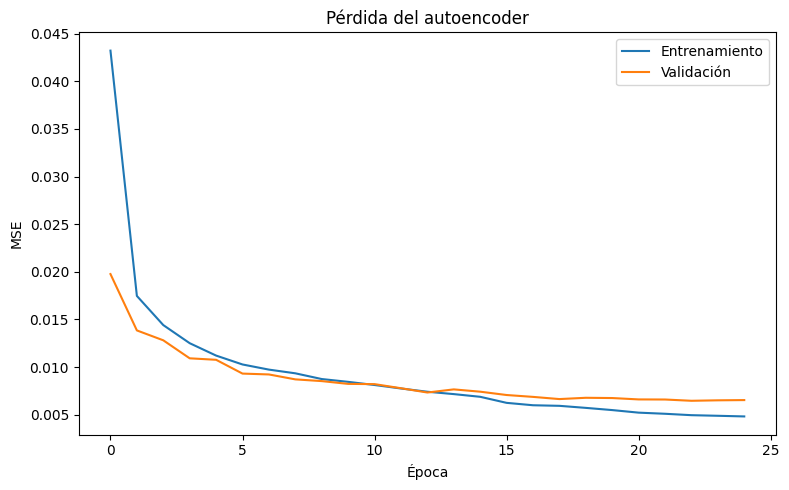

Gráfica guardada en:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/curvas_entrenamiento_autoencoder.png


In [ ]:
figura, eje = plt.subplots(
    figsize=(
        8,
        5
    )
)


eje.plot(
    historial_autoencoder.history[
        "loss"
    ],

    label="Entrenamiento"
)


eje.plot(
    historial_autoencoder.history[
        "val_loss"
    ],

    label="Validación"
)


eje.set_title(
    "Pérdida del autoencoder"
)


eje.set_xlabel(
    "Época"
)


eje.set_ylabel(
    "MSE"
)


eje.legend()


plt.tight_layout()


plt.savefig(
    RUTA_GRAFICA_PERDIDA,

    dpi=200
)


plt.show()


print("Gráfica guardada en:")
print(
    RUTA_GRAFICA_PERDIDA
)

Compara visualmente varias radiografías originales con sus reconstrucciones.

Esto permite comprobar si el autoencoder ha aprendido una representación razonable.

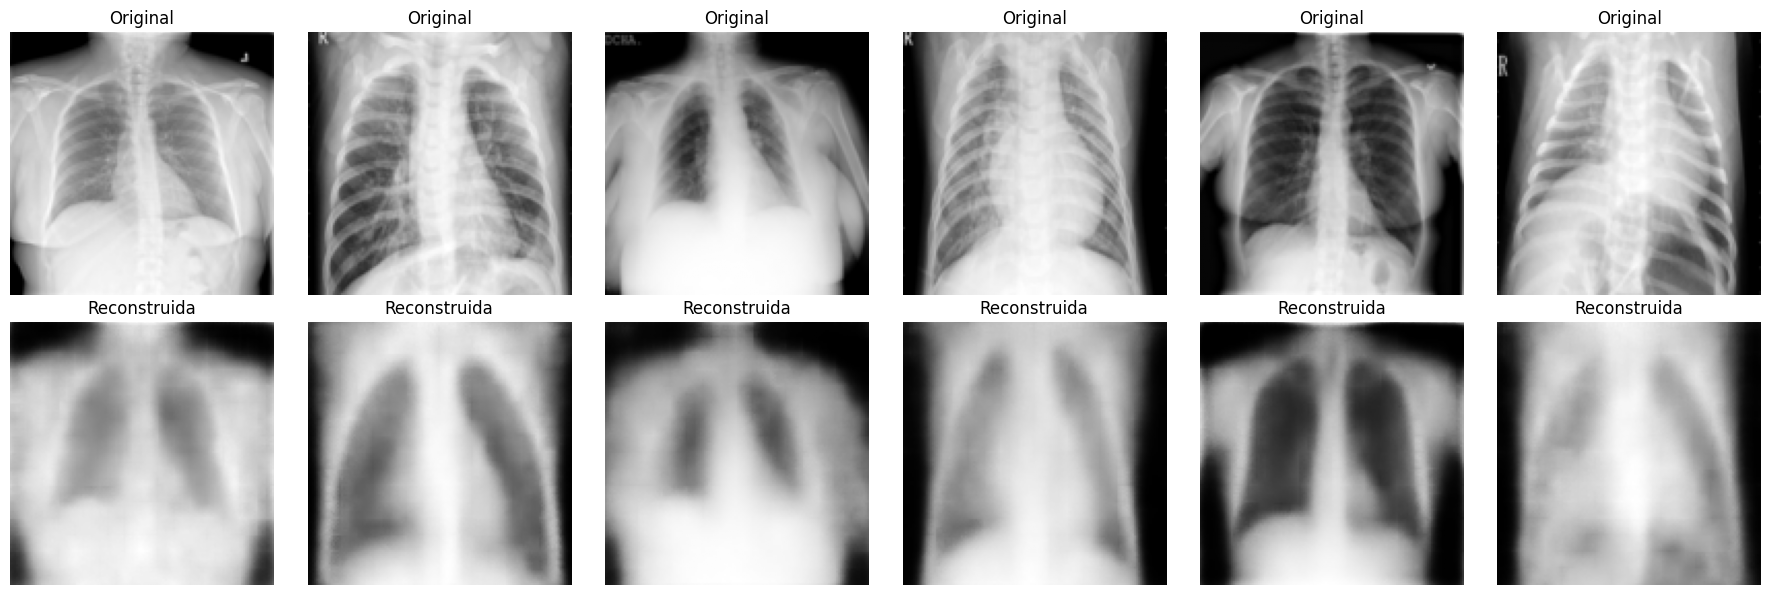

Reconstrucciones guardadas en:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/reconstrucciones_autoencoder.png


In [ ]:
lote_imagenes, lote_etiquetas = next(
    iter(
        dataset_extraccion_test.take(
            1
        )
    )
)


numero_ejemplos = min(
    6,

    lote_imagenes.shape[
        0
    ]
)


imagenes_originales = lote_imagenes[
    :numero_ejemplos
]


imagenes_reconstruidas = autoencoder.predict(
    imagenes_originales,

    verbose=0
)


figura, ejes = plt.subplots(
    nrows=2,

    ncols=numero_ejemplos,

    figsize=(
        3
        * numero_ejemplos,

        6
    )
)


for indice in range(
    numero_ejemplos
):
    ejes[
        0,
        indice
    ].imshow(
        imagenes_originales[
            indice
        ].numpy().squeeze(),

        cmap="gray"
    )

    ejes[
        0,
        indice
    ].set_title(
        "Original"
    )

    ejes[
        0,
        indice
    ].axis(
        "off"
    )


    ejes[
        1,
        indice
    ].imshow(
        imagenes_reconstruidas[
            indice
        ].squeeze(),

        cmap="gray"
    )

    ejes[
        1,
        indice
    ].set_title(
        "Reconstruida"
    )

    ejes[
        1,
        indice
    ].axis(
        "off"
    )


plt.tight_layout()


plt.savefig(
    RUTA_GRAFICA_RECONSTRUCCIONES,

    dpi=200
)


plt.show()


print("Reconstrucciones guardadas en:")
print(
    RUTA_GRAFICA_RECONSTRUCCIONES
)

Extraer vectores latentes

In [ ]:
def extraer_vectores_latentes(
    modelo_encoder,
    dataset,
    nombre_particion
):
    print(
        f"Extrayendo vectores latentes de {nombre_particion}..."
    )

    dataset_solo_imagenes = dataset.map(
        lambda imagenes, etiquetas: imagenes,

        num_parallel_calls=tf.data.AUTOTUNE
    )

    inicio = time.time()

    vectores = modelo_encoder.predict(
        dataset_solo_imagenes,

        verbose=1
    )

    tiempo = (
        time.time()
        - inicio
    )

    vectores = np.asarray(
        vectores,

        dtype=np.float32
    )

    vectores = np.nan_to_num(
        vectores,

        nan=0.0,

        posinf=0.0,

        neginf=0.0
    )

    print(
        f"\n{nombre_particion}:",
        vectores.shape
    )

    print(
        "Tiempo:",
        f"{tiempo / 60:.2f} minutos"
    )

    return vectores, tiempo


X_entrenamiento, tiempo_extraccion_entrenamiento = extraer_vectores_latentes(
    encoder,

    dataset_extraccion_entrenamiento,

    "entrenamiento"
)


X_validacion, tiempo_extraccion_validacion = extraer_vectores_latentes(
    encoder,

    dataset_extraccion_validacion,

    "validación"
)


X_test, tiempo_extraccion_test = extraer_vectores_latentes(
    encoder,

    dataset_extraccion_test,

    "test"
)


np.save(
    RUTA_FEATURES_ENTRENAMIENTO,

    X_entrenamiento
)


np.save(
    RUTA_FEATURES_VALIDACION,

    X_validacion
)


np.save(
    RUTA_FEATURES_TEST,

    X_test
)


np.save(
    RUTA_ETIQUETAS_ENTRENAMIENTO,

    y_entrenamiento
)


np.save(
    RUTA_ETIQUETAS_VALIDACION,

    y_validacion
)


np.save(
    RUTA_ETIQUETAS_TEST,

    y_test
)


print("\nVectores latentes y etiquetas guardados.")

Extrayendo vectores latentes de entrenamiento...
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

entrenamiento: (6272, 128)
Tiempo: 0.01 minutos
Extrayendo vectores latentes de validación...
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

validación: (1344, 128)
Tiempo: 0.00 minutos
Extrayendo vectores latentes de test...
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step

test: (1345, 128)
Tiempo: 0.08 minutos

Vectores latentes y etiquetas guardados.


Comprobar la reducción dimensional

In [ ]:
print("REDUCCIÓN DIMENSIONAL")
print("=" * 80)

print("\nDimensión inicial de cada imagen:")
print(
    TAMANO_IMAGEN[
        0
    ]
    * TAMANO_IMAGEN[
        1
    ]
)

print("\nDimensión del vector latente:")
print(
    X_entrenamiento.shape[
        1
    ]
)

print("\nEntrenamiento:")
print(
    X_entrenamiento.shape
)

print("\nValidación:")
print(
    X_validacion.shape
)

print("\nTest:")
print(
    X_test.shape
)


memoria_mb = (
    X_entrenamiento.nbytes
    + X_validacion.nbytes
    + X_test.nbytes
) / (
    1024
    ** 2
)


print("\nMemoria ocupada por los vectores:")
print(
    f"{memoria_mb:.2f} MB"
)

REDUCCIÓN DIMENSIONAL

Dimensión inicial de cada imagen:
16384

Dimensión del vector latente:
128

Entrenamiento:
(6272, 128)

Validación:
(1344, 128)

Test:
(1345, 128)

Memoria ocupada por los vectores:
4.38 MB


Preparar GridSearchCV

In [ ]:
modelo_rf_base = RandomForestClassifier(
    random_state=SEMILLA,

    # GridSearchCV ya paraleliza candidatos.
    # Evitamos paralelismo interno anidado.
    n_jobs=1
)


validacion_cruzada = StratifiedKFold(
    n_splits=NUMERO_FOLDS_CV,

    shuffle=True,

    random_state=SEMILLA
)


busqueda_grid = GridSearchCV(
    estimator=modelo_rf_base,

    param_grid=CUADRICULA_HIPERPARAMETROS,

    scoring="f1_macro",

    cv=validacion_cruzada,

    refit=True,

    n_jobs=N_JOBS_BUSQUEDA,

    pre_dispatch=N_JOBS_BUSQUEDA,

    verbose=2,

    return_train_score=True,

    error_score="raise"
)


print("GridSearchCV preparado.")

print("\nCuadrícula:")
print(
    CUADRICULA_HIPERPARAMETROS
)

print("\nNúmero de combinaciones:")
print(
    NUMERO_COMBINACIONES
)

print("\nNúmero aproximado de ajustes:")
print(
    NUMERO_AJUSTES_APROXIMADO
)

GridSearchCV preparado.

Cuadrícula:
{'n_estimators': [200, 400], 'max_depth': [None, 25], 'min_samples_split': [2], 'min_samples_leaf': [1], 'max_features': ['sqrt'], 'class_weight': [None, 'balanced_subsample'], 'bootstrap': [True]}

Número de combinaciones:
8

Número aproximado de ajustes:
25


Ejecuta el GridSearchCV.

Para cada combinación:

Divide internamente el entrenamiento en tres folds.
Entrena el Random Forest.
Calcula macro F1.
Compara resultados.
Escoge la mejor configuración.
Reentrena la mejor usando todos los vectores de entrenamiento.

In [ ]:
print("INICIANDO GRIDSEARCHCV")
print("=" * 80)

inicio_gridsearch = time.time()


busqueda_grid.fit(
    X_entrenamiento,

    y_entrenamiento
)


tiempo_gridsearch = (
    time.time()
    - inicio_gridsearch
)


print("\nGRIDSEARCHCV TERMINADO")
print("=" * 80)

print("\nTiempo:")
print(
    f"{tiempo_gridsearch / 60:.2f} minutos"
)

print("\nMejor macro F1 medio en validación cruzada:")
print(
    busqueda_grid.best_score_
)

print("\nMejores hiperparámetros:")
print(
    busqueda_grid.best_params_
)

INICIANDO GRIDSEARCHCV
Fitting 3 folds for each of 8 candidates, totalling 24 fits

GRIDSEARCHCV TERMINADO

Tiempo:
4.24 minutos

Mejor macro F1 medio en validación cruzada:
0.8799236310589733

Mejores hiperparámetros:
{'bootstrap': True, 'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


Guardar el Random Forest y los resultados de GridSearchCV

In [ ]:
df_resultados_gridsearch = pd.DataFrame(
    busqueda_grid.cv_results_
)


df_resultados_gridsearch = df_resultados_gridsearch.sort_values(
    by="rank_test_score"
)


df_resultados_gridsearch.to_csv(
    RUTA_RESULTADOS_GRIDSEARCH,

    index=False
)


modelo_rf_autoencoder = (
    busqueda_grid.best_estimator_
)


mejor_score_cv = (
    busqueda_grid.best_score_
)


mejores_hiperparametros = (
    busqueda_grid.best_params_
)


modelo_rf_autoencoder.set_params(
    n_jobs=-1
)


joblib.dump(
    modelo_rf_autoencoder,

    RUTA_RANDOM_FOREST
)


print("Resultados de GridSearchCV guardados en:")
print(
    RUTA_RESULTADOS_GRIDSEARCH
)

print("\nRandom Forest guardado en:")
print(
    RUTA_RANDOM_FOREST
)

print("\nMejores configuraciones:")

display(
    df_resultados_gridsearch[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
)

Resultados de GridSearchCV guardados en:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/resultados_gridsearch_autoencoder_rf.csv

Random Forest guardado en:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/random_forest_autoencoder_gridsearch.joblib

Mejores configuraciones:


,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
1,1,0.879924,0.008494,1.0,"{'bootstrap': True, 'class_weight': None, 'max..."
3,2,0.879064,0.007858,1.0,"{'bootstrap': True, 'class_weight': None, 'max..."
0,3,0.877784,0.009612,1.0,"{'bootstrap': True, 'class_weight': None, 'max..."
2,4,0.877562,0.009986,1.0,"{'bootstrap': True, 'class_weight': None, 'max..."
7,5,0.874841,0.010856,1.0,"{'bootstrap': True, 'class_weight': 'balanced_..."
5,6,0.874563,0.008984,1.0,"{'bootstrap': True, 'class_weight': 'balanced_..."
4,7,0.873553,0.009350,1.0,"{'bootstrap': True, 'class_weight': 'balanced_..."
6,8,0.873164,0.009618,1.0,"{'bootstrap': True, 'class_weight': 'balanced_..."


Evaluar validación y test

In [ ]:
predicciones_validacion = modelo_rf_autoencoder.predict(
    X_validacion
)


predicciones_test = modelo_rf_autoencoder.predict(
    X_test
)


accuracy_validacion = accuracy_score(
    y_validacion,

    predicciones_validacion
)


macro_f1_validacion = f1_score(
    y_validacion,

    predicciones_validacion,

    average="macro"
)


accuracy_test = accuracy_score(
    y_test,

    predicciones_test
)


macro_f1_test = f1_score(
    y_test,

    predicciones_test,

    average="macro"
)


reporte_validacion = classification_report(
    y_validacion,

    predicciones_validacion,

    labels=list(
        range(
            len(
                CLASES
            )
        )
    ),

    target_names=CLASES,

    digits=4,

    zero_division=0
)


reporte_test = classification_report(
    y_test,

    predicciones_test,

    labels=list(
        range(
            len(
                CLASES
            )
        )
    ),

    target_names=CLASES,

    digits=4,

    zero_division=0
)


print("=" * 80)
print("AUTOENCODER + RANDOM FOREST - VALIDACIÓN")
print("=" * 80)

print("\nAccuracy:")
print(
    accuracy_validacion
)

print("\nMacro F1:")
print(
    macro_f1_validacion
)

print("\nReporte:")
print(
    reporte_validacion
)


print("\n" + "=" * 80)
print("AUTOENCODER + RANDOM FOREST - TEST")
print("=" * 80)

print("\nAccuracy:")
print(
    accuracy_test
)

print("\nMacro F1:")
print(
    macro_f1_test
)

print("\nReporte:")
print(
    reporte_test
)

AUTOENCODER + RANDOM FOREST - VALIDACIÓN

Accuracy:
0.8861607142857143

Macro F1:
0.8948145773571768

Reporte:
                 precision    recall  f1-score   support

          COVID     0.8574    0.8985    0.8775       542
         Normal     0.9049    0.8567    0.8801       600
Viral Pneumonia     0.9135    0.9406    0.9268       202

       accuracy                         0.8862      1344
      macro avg     0.8919    0.8986    0.8948      1344
   weighted avg     0.8870    0.8862    0.8861      1344


AUTOENCODER + RANDOM FOREST - TEST

Accuracy:
0.8795539033457249

Macro F1:
0.8876192768706611

Reporte:
                 precision    recall  f1-score   support

          COVID     0.8425    0.9061    0.8731       543
         Normal     0.8979    0.8500    0.8733       600
Viral Pneumonia     0.9378    0.8960    0.9165       202

       accuracy                         0.8796      1345
      macro avg     0.8927    0.8840    0.8876      1345
   weighted avg     0.8815    0.8796 

Crear matriz de confusión

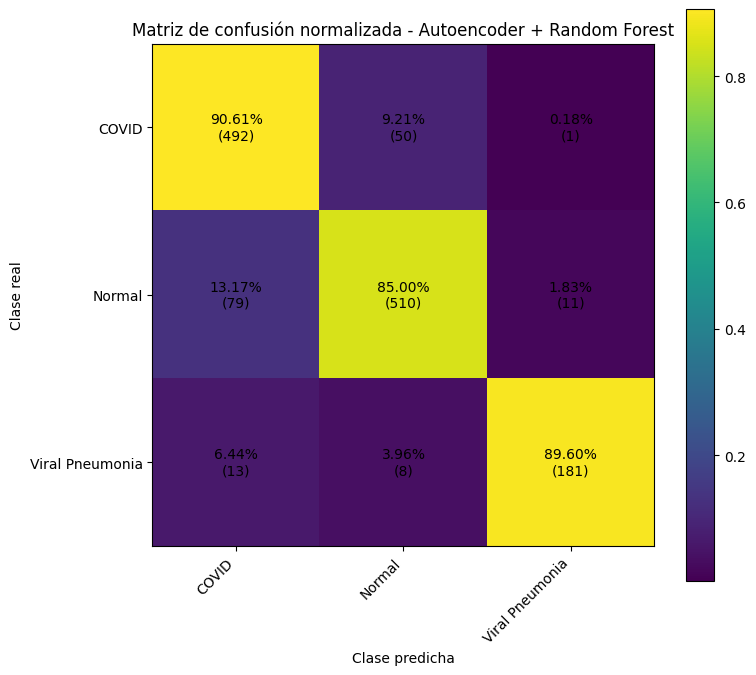

Matriz de confusión guardada en:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/matriz_confusion_autoencoder_random_forest.csv


In [ ]:
matriz_confusion = confusion_matrix(
    y_test,

    predicciones_test,

    labels=list(
        range(
            len(
                CLASES
            )
        )
    )
)


matriz_confusion_normalizada = (
    matriz_confusion.astype(
        "float"
    )
    / np.maximum(
        matriz_confusion.sum(
            axis=1
        )[
            :,
            np.newaxis
        ],

        1
    )
)


df_matriz_confusion = pd.DataFrame(
    matriz_confusion,

    index=CLASES,

    columns=CLASES
)


df_matriz_confusion.to_csv(
    RUTA_MATRIZ_CONFUSION
)


figura, eje = plt.subplots(
    figsize=(
        8,
        7
    )
)


imagen = eje.imshow(
    matriz_confusion_normalizada
)


eje.set_title(
    "Matriz de confusión normalizada - Autoencoder + Random Forest"
)


eje.set_xlabel(
    "Clase predicha"
)


eje.set_ylabel(
    "Clase real"
)


eje.set_xticks(
    np.arange(
        len(
            CLASES
        )
    )
)


eje.set_yticks(
    np.arange(
        len(
            CLASES
        )
    )
)


eje.set_xticklabels(
    CLASES,

    rotation=45,

    ha="right"
)


eje.set_yticklabels(
    CLASES
)


for i in range(
    len(
        CLASES
    )
):
    for j in range(
        len(
            CLASES
        )
    ):
        porcentaje = (
            matriz_confusion_normalizada[
                i,
                j
            ]
            * 100
        )

        valor_absoluto = (
            matriz_confusion[
                i,
                j
            ]
        )

        eje.text(
            j,

            i,

            f"{porcentaje:.2f}%\n({valor_absoluto})",

            ha="center",

            va="center"
        )


plt.colorbar(
    imagen
)


plt.tight_layout()


plt.show()


print("Matriz de confusión guardada en:")
print(
    RUTA_MATRIZ_CONFUSION
)

Guardar el resumen del experimento

In [ ]:
tiempo_extraccion_total = (
    tiempo_extraccion_entrenamiento
    + tiempo_extraccion_validacion
    + tiempo_extraccion_test
)


with open(
    RUTA_RESUMEN,

    "w",

    encoding="utf-8"
) as archivo:
    archivo.write(
        "AUTOENCODER CONVOLUCIONAL + RANDOM FOREST\n"
    )

    archivo.write(
        "=" * 80
    )

    archivo.write(
        "\n\nClases:\n"
    )

    for clase in CLASES:
        archivo.write(
            f"- {clase}\n"
        )

    archivo.write(
        "\nTamaño de imagen:\n"
    )

    archivo.write(
        str(
            TAMANO_IMAGEN
        )
    )

    archivo.write(
        "\n\nDimensión inicial:\n"
    )

    archivo.write(
        str(
            TAMANO_IMAGEN[
                0
            ]
            * TAMANO_IMAGEN[
                1
            ]
        )
    )

    archivo.write(
        "\n\nDimensión latente:\n"
    )

    archivo.write(
        str(
            DIMENSION_LATENTE
        )
    )

    archivo.write(
        "\n\nÉpocas ejecutadas:\n"
    )

    archivo.write(
        str(
            len(
                historial_autoencoder.history[
                    "loss"
                ]
            )
        )
    )

    archivo.write(
        "\n\nTiempo de entrenamiento del autoencoder en minutos:\n"
    )

    archivo.write(
        str(
            tiempo_entrenamiento_autoencoder
            / 60
        )
    )

    archivo.write(
        "\n\nTiempo de extracción de vectores en minutos:\n"
    )

    archivo.write(
        str(
            tiempo_extraccion_total
            / 60
        )
    )

    archivo.write(
        "\n\nNúmero de combinaciones GridSearchCV:\n"
    )

    archivo.write(
        str(
            NUMERO_COMBINACIONES
        )
    )

    archivo.write(
        "\n\nNúmero de folds:\n"
    )

    archivo.write(
        str(
            NUMERO_FOLDS_CV
        )
    )

    archivo.write(
        "\n\nTiempo de GridSearchCV en minutos:\n"
    )

    archivo.write(
        str(
            tiempo_gridsearch
            / 60
        )
    )

    archivo.write(
        "\n\nMejor macro F1 medio en validación cruzada:\n"
    )

    archivo.write(
        str(
            mejor_score_cv
        )
    )

    archivo.write(
        "\n\nMejores hiperparámetros:\n"
    )

    archivo.write(
        json.dumps(
            mejores_hiperparametros,

            indent=4,

            default=str
        )
    )

    archivo.write(
        "\n\nAccuracy de validación:\n"
    )

    archivo.write(
        str(
            accuracy_validacion
        )
    )

    archivo.write(
        "\n\nMacro F1 de validación:\n"
    )

    archivo.write(
        str(
            macro_f1_validacion
        )
    )

    archivo.write(
        "\n\nReporte de validación:\n"
    )

    archivo.write(
        reporte_validacion
    )

    archivo.write(
        "\n\nAccuracy de test:\n"
    )

    archivo.write(
        str(
            accuracy_test
        )
    )

    archivo.write(
        "\n\nMacro F1 de test:\n"
    )

    archivo.write(
        str(
            macro_f1_test
        )
    )

    archivo.write(
        "\n\nReporte de test:\n"
    )

    archivo.write(
        reporte_test
    )


print("Resumen guardado en:")
print(
    RUTA_RESUMEN
)

Resumen guardado en:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/resumen_autoencoder_random_forest.txt


Mostrar archivos generados

In [ ]:
print("ARCHIVOS GENERADOS")
print("=" * 80)

print("\nCSV de particiones:")
print(
    RUTA_PARTICIONES
)

print("\nMejor autoencoder:")
print(
    RUTA_AUTOENCODER_MEJOR
)

print("\nAutoencoder final:")
print(
    RUTA_AUTOENCODER_FINAL
)

print("\nEncoder:")
print(
    RUTA_ENCODER
)

print("\nRandom Forest:")
print(
    RUTA_RANDOM_FOREST
)

print("\nResultados de GridSearchCV:")
print(
    RUTA_RESULTADOS_GRIDSEARCH
)

print("\nResumen:")
print(
    RUTA_RESUMEN
)

print("\nCurvas de entrenamiento:")
print(
    RUTA_GRAFICA_PERDIDA
)

print("\nReconstrucciones:")
print(
    RUTA_GRAFICA_RECONSTRUCCIONES
)

print("\nMatriz de confusión:")
print(
    RUTA_MATRIZ_CONFUSION
)

ARCHIVOS GENERADOS

CSV de particiones:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/particiones_autoencoder.csv

Mejor autoencoder:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/autoencoder_convolucional_mejor.keras

Autoencoder final:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/autoencoder_convolucional_final.keras

Encoder:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/encoder_convolucional.keras

Random Forest:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/random_forest_autoencoder_gridsearch.joblib

Resultados de GridSearchCV:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/resultados_gridsearch_autoencoder_rf.csv

Resumen:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/resumen_autoencoder_random_forest.txt

Curvas de entrenamiento:
/content/drive/MyDrive/TFG/modelos autoencoder random forest/curvas_entrenamiento_autoencoder.png

Reconstrucciones:
/content/drive/MyDrive/TFG/mod